# Single-variate Linear Regression without Bias Term

## Programming Lab: 02 Gradient Descent Method

이번 실습에서는 기본적인 NumPy와 Matplotlib의 사용법을 익히고, Gradient Descent Method을 이용하여 predictor를 학습시켜 봅니다.

PA 03-01은 다음과 같은 단계로 이루어집니다.

<ul>
    <li> Step.1 Dataset Generation </li>    
    NumPy를 이용하여 학습에 필요한 dataset을 만듭니다.
    <li> Step.2 Stochastic Gradient Descent Method </li>
    SGD 방법을 이용하여 predictor를 학습시킵니다.
    <li> Step.3 Predictor Visualization </li>
    predictor가 학습되는 모습을 시각화하여 제대로 학습이 일어나는지 확인합니다.        
</ul>

***
먼저 다음 셀을 실행시켜 필요한 library들을 import하세요.

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

np.random.seed(0)

***
## Step.1 Dataset Generation

### Target Function
linear regression model을 학습시키기 위한 dataset을 먼저 만들어봅니다. dataset은

$$y = 3x$$

에서부터 만들어지며, 따라서 target function은 $y = 3x$입니다.

***
**Programming**

먼저 x값을 기준으로 -3부터 3까지 target function을 그려봅니다.

(Hint.1) 직선을 그리기 위해선 시작점, 끝점 2개가 필요합니다. np.linspace()을 사용하여 2개 점을 생성합니다.

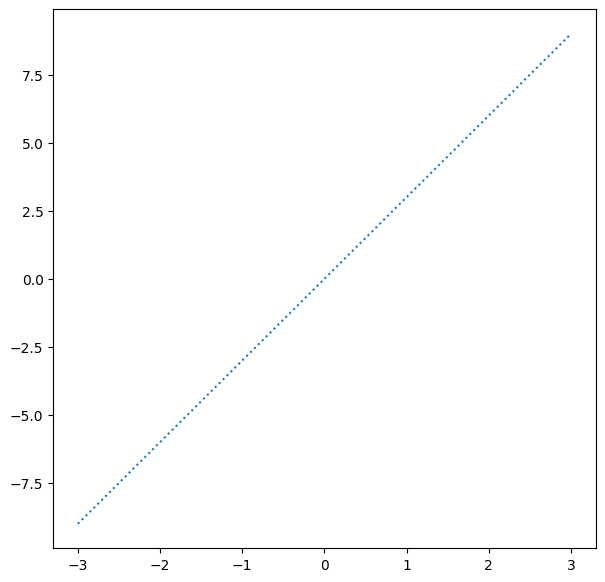

In [52]:
##### Start Your Code(Target Function) #####
t_x = np.linspace(-3, 3, 2)
t_y = 3 * t_x
##### End Your Code(Target Function) #####

fig, ax = plt.subplots(figsize = (7,7))
ax.plot(t_x, t_y, linestyle = ':')

**Expected Output**  
<img src="./imgs/3_01_01.png" width = 300>

### Data Samples

signle-variate linear regression의 dataset은 1개의 x값과 그에 따른 1개의 y값으로 이루어집니다.

그리고 target function과 같은 함수에서부터 만들어지며 Gaussian noise가 추가됩니다.

***
**Programming**

이번 실습에서는 100개의 data sample들을 standard normal distribution에서부터 만들고, noise도 마찬가지로 standard normal distribution에서부터 만들어진 Gaussian noise를 추가합니다. 이때 Gaussian noise에 0.5를 곱해줍니다.

(Hint.1) n_sample을 100으로 설정  
(Hint.2) x_data에 np.random.normal( )을 사용하여 n_sample만큼의 샘플 생성하는데 평균 0, 표준편차 1로 설정  
(Hint.3) y_data = 3 * x_data + noise 의 방식으로 y_data 생성  

Text(0, 0.5, 'y data')

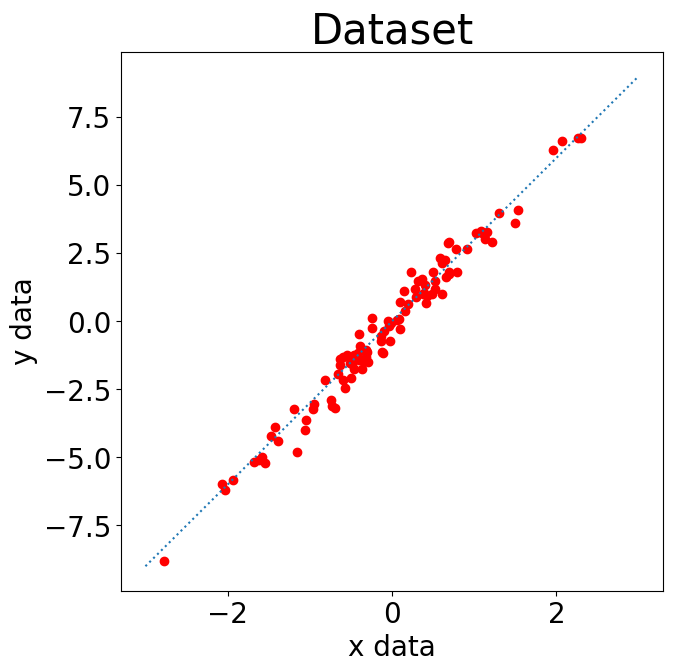

In [56]:
##### Start Your Code(Dataset Generation) #####
n_sample = 100
x_data = np.random.normal(0, 1, (n_sample,))
y_data = 3 * x_data + 0.5 * np.random.normal(0, 1, (n_sample,))
##### End Your Code(Dataset Generation) #####

# Target Function Visualization
fig, ax = plt.subplots(figsize = (7,7))
ax.plot(t_x, t_y, linestyle = ':')

# Dataset Visualization
ax.scatter(x_data, y_data, color = 'r')
ax.tick_params(axis = 'both', labelsize = 20)
ax.set_title("Dataset", fontsize = 30)
ax.set_xlabel("x data", fontsize = 20)
ax.set_ylabel("y data", fontsize = 20)

**Expected Output**  
<img src="./imgs/3_01_02.png" width = 400>

***
## Step.2 Stochastic Gradient Descent Method

위의 dataset에 따라 predictor는
$$ \hat{y} = w x$$
로 설정할 수 있습니다.

그리고 $i$번째 data sample에 대한 loss($\mathcal{L}^{(i)}$)는 
$$ \mathcal{L}^{(i)} = (\hat{y}^{(i)} - y^{(i)})^{2} = (w x^{(i)} - y^{(i)})^{2}$$
로 정의됩니다.

따라서 $w$에 대한 $\mathcal{L}^{(i)}$의 partial derivative는
$$ \frac{\partial \mathcal{L}^{(i)}}{\partial w} = 2x^{(i)}(\hat{y}^{(i)} - y^{(i)})$$
입니다.

마지막으로 이를 이용한 Gradient descent method는

$$ w := w - \alpha \frac{\partial \mathcal{L}^{(i)}}{\partial w}$$

$$ = w - 2\alpha x^{(i)}(\hat{y}^{(i)} - y^{(i)})$$
입니다.

***
**Programming**

초기 $w$는 0.1, learning rate(lr)는 0.001, 총 epoch(epochs)는 50으로 설정하고 gradient descent method를 이용하여 optimal $w$에 대한 approximation을 진행하세요.

(Hint.1) $w$의 변화와 loss를 추적하기 위하여 빈 리스트 w_list, loss_list를 각각 만들어줍니다.

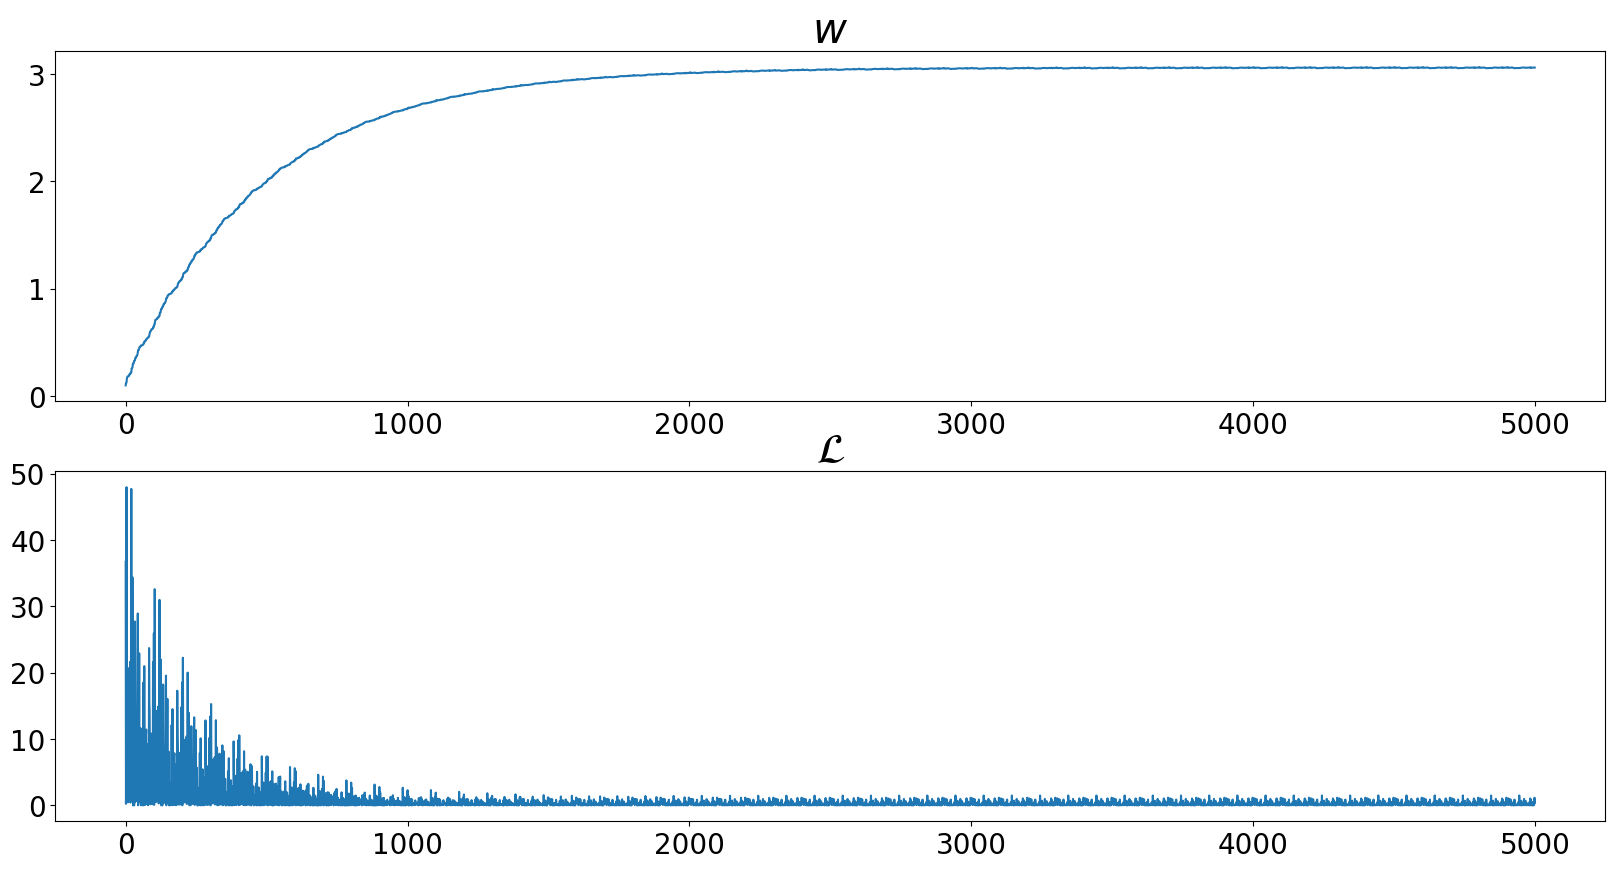

In [54]:
##### Start Your Code(Learning Preparation) #####
w = 0.1
lr = 0.001
epochs = 50
##### End Your Code(Learning Preparation) #####

w_list = []
loss_list = []

for epoch in range(epochs):
    for data_idx, (x, y) in enumerate(zip(x_data, y_data)):
        ##### Start Your Code(Loss Calculation) #####
        pred = w * x
        loss = (pred - y) ** 2
        ##### End Your Code(Loss Calculation) #####

        w_list.append(w)
        loss_list.append(loss)
        
        ##### Start Your Code(Gradient Descent Method) #####
        w = w - ((2 * lr * x) * (pred - y))
        ##### End Your Code(Gradient Descent Method) #####
        
fig, ax = plt.subplots(2, 1, figsize = (20,10))
ax[0].plot(w_list)
ax[1].plot(loss_list)
ax[0].set_title(r'$w$', fontsize = 30)
ax[1].set_title(r'$\mathcal{L}$', fontsize = 30)
for ax_idx in range(2):
    ax[ax_idx].tick_params(axis = 'both', labelsize = 20)

**Expected Output**
<img src="./imgs/3_01_03.png">

***
## Step.3 Predictor Visualization

다음 셀을 실행하여 초기 predictor $\hat{y} = 3x$가 학습을 거쳐 dataset을 잘 표현하는 predictor로 학습되는지 확인하세요.

C:\Users\stu04\AppData\Local\Temp\ipykernel_24580\1447208912.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('rainbow', lut = len(w_list))


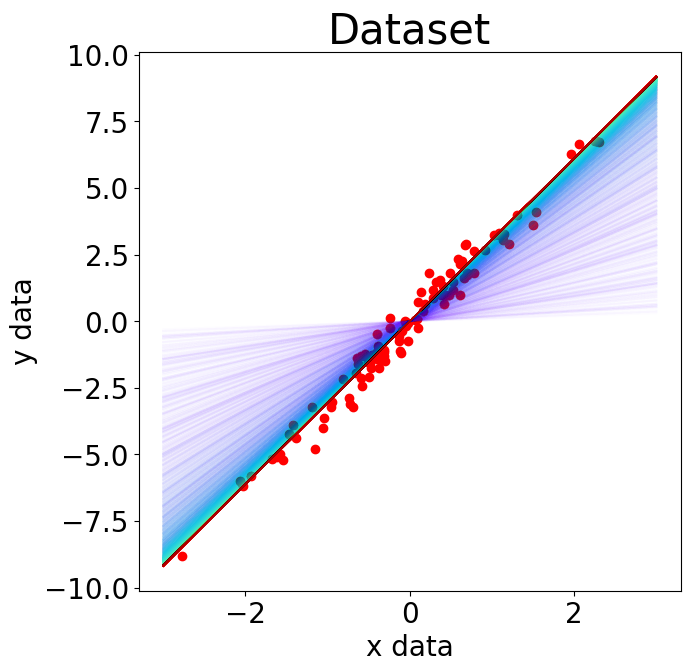

In [57]:
fig, ax = plt.subplots(figsize = (7,7))
ax.scatter(x_data, y_data, color = 'r')
ax.tick_params(axis = 'both', labelsize = 20)
ax.set_title("Dataset", fontsize = 30)
ax.set_xlabel("x data", fontsize = 20)
ax.set_ylabel("y data", fontsize = 20)

x_range = np.linspace(-3, 3, 2)
cmap = cm.get_cmap('rainbow', lut = len(w_list))
for w_idx, w in enumerate(w_list):
    predictor = w*x_range
    ax.plot(x_range, predictor,
            color = cmap(w_idx),
            alpha = 0.01)

**Expected Output**
<img src="./imgs/3_01_04.png" width = 400>